# QSAM project

In this project we will explore a dataset with the following columns:
- **RowNumber**—corresponds to the record number.
- **CustomerId**—contains the identification number of the client.
- **Surname**—the surname of the customer.
- **CreditScore**—can have an effect on customer churn, since a customer with a higher credit score is less likely to 
leave the bank.
- **Geography**—the customer’s location.
- **Gender**—the customer's gender.
- **Age**—this is certainly relevant, since older customers are less likely to leave their bank than younger ones.
- **Tenure**—refers to the number of years that the customer has been a client of the bank. Normally, older clients are more loyal and less likely to leave a bank.
- **Balance**—also a very good indicator of customer churn, as people with a higher balance in their accounts are less likely to leave the bank compared to those with lower balances.
- **NumOfProducts**—refers to the number of products that a customer has purchased through the bank.
- **HasCrCard**—denotes whether or not a customer has a credit card. This column is also relevant, since people with a credit card are less likely to leave the bank.
- **IsActiveMember**—active customers are less likely to leave the bank.
- **EstimatedSalary**—as with balance, people with lower salaries are more likely to leave the bank compared to those with higher salaries.
- **Exited**—whether or not the customer left the bank.
- **Complain**—customer has complaint or not.
- **Satisfaction Score**—Score provided by the customer for their complaint resolution.
- **Card Type**—type of card hold by the customer.
- **Points Earned**—the points earned by the customer for using credit card.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy import stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve


In [5]:
data = pd.read_csv("data/Customer-Churn-Records.csv")
data.set_index('CustomerId', inplace=True)

## Context

You are a Data Scientists that needs to reply to certain questions, some of them comming directly from the business intelligence team and some others related to your main mission, understand the data to create a Machine Learning algorithm in order to predict if a customer will leave the bank or not.

In [6]:
display(data.head())
data.shape

,RowNumber,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
CustomerId,,,,,,,,,,,,,,,,,
15634602,1,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
15647311,2,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
15619304,3,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
15701354,4,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
15737888,5,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


(10000, 17)

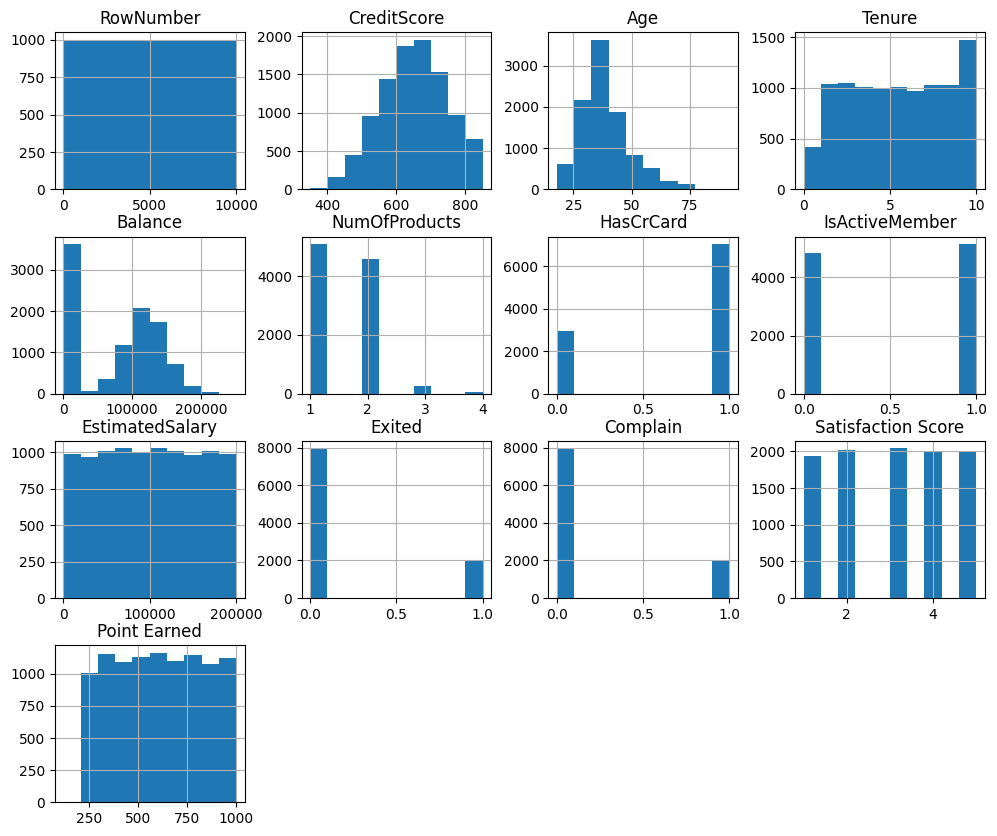

In [7]:
data.hist(figsize=(12,10));

In [8]:
data.isnull().sum()

RowNumber             0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

In [9]:
new_data = data.drop(columns=['Surname', 'RowNumber'])
new_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 15634602 to 15628319
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CreditScore         10000 non-null  int64  
 1   Geography           10000 non-null  object 
 2   Gender              10000 non-null  object 
 3   Age                 10000 non-null  int64  
 4   Tenure              10000 non-null  int64  
 5   Balance             10000 non-null  float64
 6   NumOfProducts       10000 non-null  int64  
 7   HasCrCard           10000 non-null  int64  
 8   IsActiveMember      10000 non-null  int64  
 9   EstimatedSalary     10000 non-null  float64
 10  Exited              10000 non-null  int64  
 11  Complain            10000 non-null  int64  
 12  Satisfaction Score  10000 non-null  int64  
 13  Card Type           10000 non-null  object 
 14  Point Earned        10000 non-null  int64  
dtypes: float64(2), int64(10), object(3)
memory usage

In [10]:
X = new_data.drop(columns=['Exited'])
y = new_data['Exited']
x_train, x_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [11]:
categorical_cols = x_train.select_dtypes(include=['object']).columns
numerical_cols = x_train.select_dtypes(include=['int64', 'float64']).columns

In [12]:
print(x_train[categorical_cols].nunique())
print(x_train[categorical_cols].value_counts())
display(x_train[numerical_cols].describe())

Geography    3
Gender       2
Card Type    4
dtype: int64
Geography  Gender  Card Type
France     Male    GOLD         570
                   PLATINUM     545
                   SILVER       540
                   DIAMOND      521
           Female  SILVER       483
                   PLATINUM     464
                   DIAMOND      457
                   GOLD         414
Spain      Male    GOLD         300
                   DIAMOND      292
Germany    Male    GOLD         277
                   PLATINUM     267
Spain      Male    PLATINUM     265
                   SILVER       265
Germany    Male    DIAMOND      262
                   SILVER       258
           Female  DIAMOND      252
                   PLATINUM     238
Spain      Female  PLATINUM     236
Germany    Female  GOLD         236
                   SILVER       221
Spain      Female  DIAMOND      220
                   SILVER       215
                   GOLD         202
Name: count, dtype: int64


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Complain,Satisfaction Score,Point Earned
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,651.647625,38.897750,5.003875,76102.139645,1.531375,0.703500,0.512750,100431.289764,0.206375,3.011000,606.767000
std,96.366200,10.518953,2.881822,62461.005757,0.579705,0.456743,0.499869,57518.920431,0.404728,1.404235,224.952574
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,90.070000,0.000000,1.000000,163.000000
25%,585.000000,32.000000,3.000000,0.000000,1.000000,0.000000,0.000000,51364.125000,0.000000,2.000000,411.000000
50%,653.000000,37.000000,5.000000,96447.520000,1.000000,1.000000,1.000000,100487.720000,0.000000,3.000000,604.000000
75%,719.000000,44.000000,7.000000,127611.332500,2.000000,1.000000,1.000000,149595.842500,0.000000,4.000000,799.250000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199970.740000,1.000000,5.000000,1000.000000


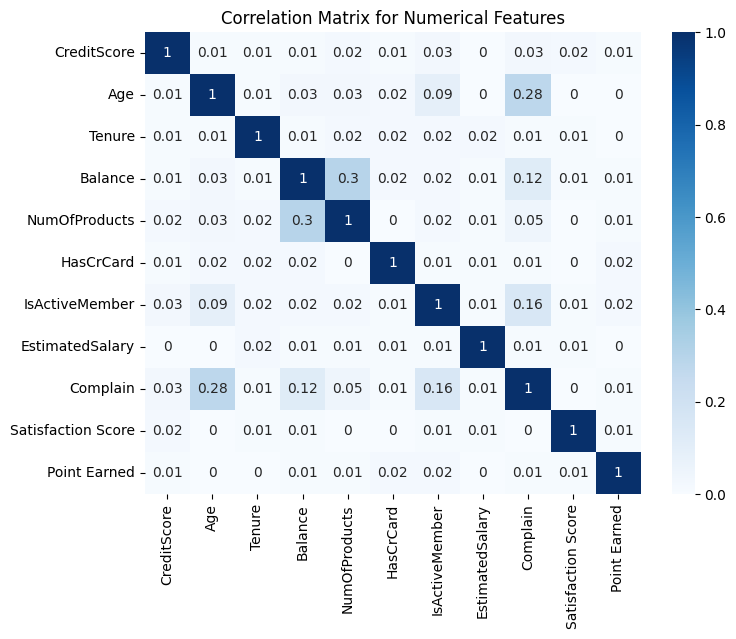

In [13]:
corr_mat = x_train[numerical_cols].corr().round(2).abs()
plt.figure(figsize=(8,6))
sns.heatmap(corr_mat, annot=True, cmap='Blues')
plt.title('Correlation Matrix for Numerical Features')
plt.show()

              precision    recall  f1-score   support

           0     0.9994    0.9994    0.9994      1607
           1     0.9975    0.9975    0.9975       393

    accuracy                         0.9990      2000
   macro avg     0.9984    0.9984    0.9984      2000
weighted avg     0.9990    0.9990    0.9990      2000



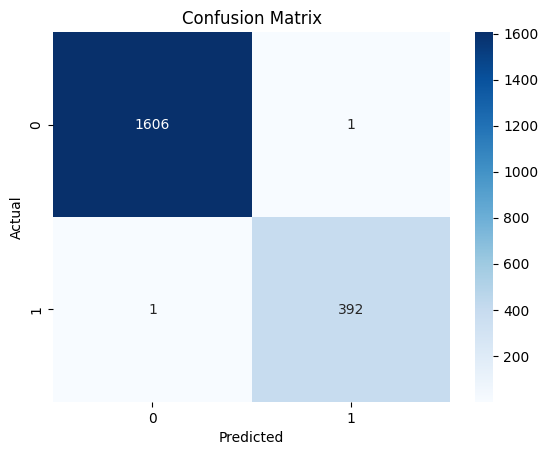

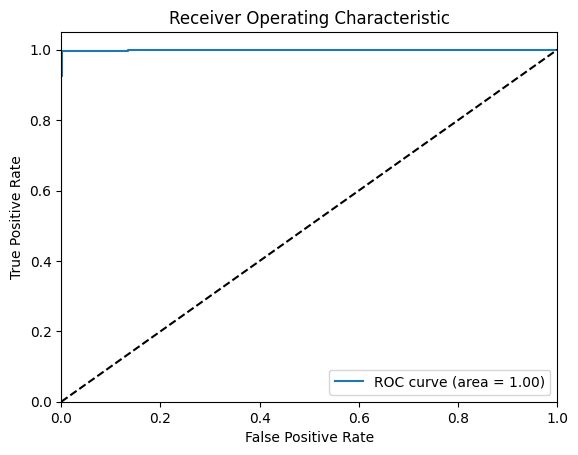

In [19]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
scaler = StandardScaler()
preprocessor = ColumnTransformer(
    transformers=[
        ('num', scaler, numerical_cols),
        ('cat', ohe, categorical_cols)
    ])
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
y_pred_proba = model.predict_proba(x_test)[:, 1]    
print(classification_report(y_test, y_pred, digits=4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
roc_auc = roc_auc_score(y_test, y_pred_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()